# BÁO CÁO PHÂN TÍCH: VÒNG ĐỜI KHÁCH HÀNG & CHIẾN LƯỢC RETENTION

*Customer Lifecycle · Cohort Retention · LTV · Acquisition ROI*

**Datathon 2026 — VinTelligence × VinUniversity Data Science & AI Club**

---


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all_tables

sns.set_theme(style='whitegrid', palette='muted')
tables = load_all_tables()
orders = tables['orders']
customers = tables['customers']
order_items = tables['order_items']

## PHẦN 1. Xác định Vấn đề và Mục tiêu Phân tích

**Vấn đề kinh doanh:** Doanh nghiệp thời trang e-commerce đang đối mặt với bài toán churn cao và chi phí acquisition tăng. Hiểu rõ vòng đời khách hàng — từ kênh thu hút, hành vi mua lại đến giá trị trọn đời (LTV) — là nền tảng để tối ưu hóa ngân sách marketing và xây dựng chiến lược giữ chân hiệu quả.

**Thách thức phân tích:**
* **Attribution gap:** ~20% khách có kênh acquisition là "Unknown" — làm mờ ROI thực tế của từng kênh.
* **Churn cliff:** Retention giảm cực nhanh sau tháng đầu tiên — onboarding là bottleneck cốt lõi.
* **LTV phân tán:** LTV chênh lệch lớn giữa các nhóm tuổi và kênh, nhưng ít được khai thác để phân bổ ngân sách.

**Cấu trúc phân tích:** Đi theo 4 cấp độ — Mô tả → Chẩn đoán → Dự đoán → Đề xuất — cuối cùng định lượng ROI của chiến lược tái phân bổ ngân sách acquisition.


---

## 🗺️ Lộ trình Phân tích — 4 Cấp độ

| Cấp độ | Câu hỏi | Phần |
|--------|---------|------|
| 🔍 **Descriptive** — Mô tả: *"Điều gì đã xảy ra?"* | Khách mới theo năm, phân bổ kênh acquisition | PHẦN 2, 3 |
| 🔬 **Diagnostic** — Chẩn đoán: *"Tại sao?"* | Repeat rate theo kênh, khoảng cách đơn → nguy cơ churn | PHẦN 4, 5 |
| 📈 **Predictive** — Dự đoán: *"Điều gì sẽ xảy ra?"* | Cohort retention forecast, revenue-at-risk, churn cliff projection | PHẦN 7 |
| 💡 **Prescriptive** — Đề xuất: *"Nên làm gì?"* | LTV theo kênh + nhóm tuổi → ROI reallocation scenario | PHẦN 6, 7 (Prescriptive block) |

> **Dữ liệu kết hợp (cross-table):** `customers` × `orders` × `order_items` × `payments` — 4 bảng, join theo `customer_id` và `order_id`


---

## PHẦN 2. Khách hàng mới theo năm
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Đếm số khách đăng ký theo năm để quan sát xu hướng acquisition.

> **Mục tiêu:** Phát hiện thay đổi về hiệu quả acquisition theo thời gian và mùa chiến dịch.


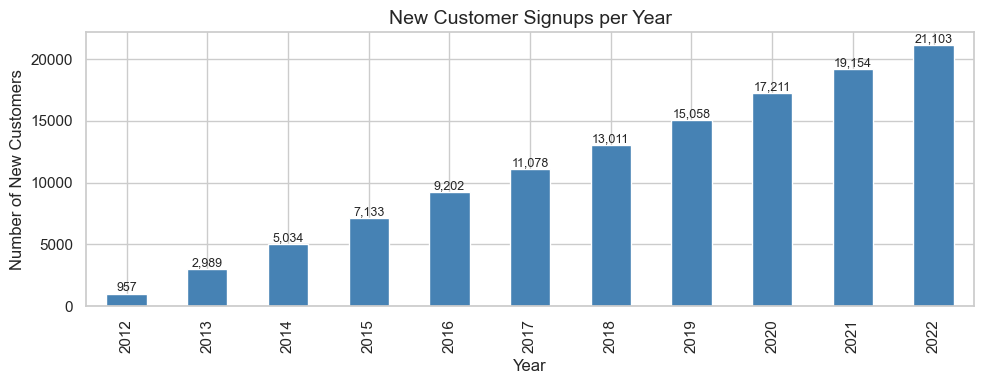

In [2]:
customers['signup_year'] = customers['signup_date'].dt.year
new_per_year = customers.groupby('signup_year').size()

fig, ax = plt.subplots(figsize=(10, 4))
new_per_year.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('New Customer Signups per Year', fontsize=14)
ax.set_xlabel('Year'); ax.set_ylabel('Number of New Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Số lượng khách hàng mới mỗi năm cho thấy xu hướng tăng trưởng acquisition theo thời gian, tuy nhiên có những năm biến động lớn (có thể do COVID hoặc thay đổi ngân sách marketing).

**💡 Hàm ý Kinh doanh:**

* Tốc độ tăng trưởng acquisition cần đối chiếu với retention rate — acquisition nhiều nhưng nếu churn nhanh thì net growth thực tế có thể âm.


---

## PHẦN 3. Phân bổ kênh thu hút khách hàng
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Hiển thị tỷ lệ khách theo kênh acquisition để đánh giá nguồn traffic.

> **Mục tiêu:** Xác định kênh có volume lớn và nguồn dữ liệu thiếu (Unknown) để ưu tiên phân tích.


In [ ]:
channel = customers['acquisition_channel'].fillna('Unknown').value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
channel.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Customer Acquisition Channels', fontsize=14)
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Acquisition Channel')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Các kênh acquisition có volume rất không đồng đều — một số kênh chiếm áp đảo số lượng khách mới.
* Một lượng đáng kể khách được ghi nhận là "Unknown" channel, đây là khoảng trống attribution cần khắc phục để phân bổ ngân sách marketing chính xác hơn.

**💡 Hàm ý Kinh doanh:**

* Ưu tiên fix tracking attribution (UTM tagging) trước khi tăng ngân sách — nếu không biết kênh nào đang hiệu quả, mọi quyết định phân bổ ngân sách đều là đoán mò.


---

## PHẦN 4. Tỷ lệ mua lại theo kênh thu hút
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* So sánh tỷ lệ repeat purchase giữa các kênh để đánh giá chất lượng khách.

> **Mục tiêu:** Chỉ ra kênh nào tạo khách hàng trung thành, hỗ trợ quyết định phân bổ ngân sách.


C:\Users\vinhn\AppData\Local\Temp\ipykernel_18856\1121705188.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


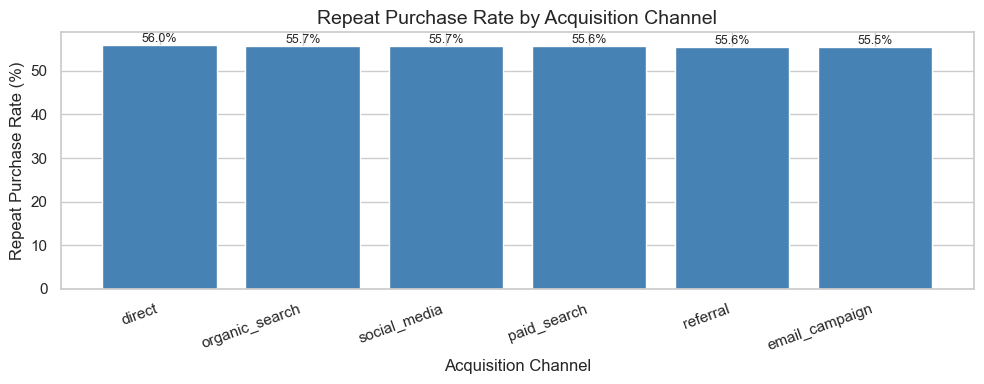


Repeat rate by channel:
acquisition_channel
direct            56.0
organic_search    55.7
social_media      55.7
paid_search       55.6
referral          55.6
email_campaign    55.5


In [4]:
order_counts = orders.groupby('customer_id').size().reset_index(name='n_orders')
cust_merged = customers.merge(order_counts, on='customer_id', how='left').fillna({'n_orders': 0})
cust_merged['is_repeat'] = (cust_merged['n_orders'] > 1).astype(int)
repeat_by_channel = cust_merged.groupby('acquisition_channel')['is_repeat'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(repeat_by_channel.index, repeat_by_channel.values * 100, color='steelblue')
ax.set_title('Repeat Purchase Rate by Acquisition Channel', fontsize=14)
ax.set_xlabel('Acquisition Channel')
ax.set_ylabel('Repeat Purchase Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for bar, val in zip(bars, repeat_by_channel.values):
    ax.annotate(f'{val*100:.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('\nRepeat rate by channel:')
print((repeat_by_channel * 100).round(1).to_string())

---

### 🔍 Kết luận Phân tích

* Repeat purchase rate chênh lệch đáng kể giữa các kênh — kênh tốt nhất có tỷ lệ mua lại cao hơn gấp đôi kênh thấp nhất.
* Điều này có nghĩa kênh volume lớn không nhất thiết là kênh chất lượng tốt.

**💡 Hàm ý Kinh doanh:**

* Không nên chỉ tối ưu hóa theo số lượng khách acquisition — cần chuyển KPI sang "qualified customers" (khách có repeat purchase ≥ 1 lần trong 90 ngày).


---

## PHẦN 5. Phân phối khoảng cách đơn hàng → dự đoán nguy cơ rời bỏ
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Phân tích khoảng cách giữa các đơn để dùng làm proxy nguy cơ churn.

> **Mục tiêu:** Xác định ngưỡng thời gian rủi ro và tạo feature cho mô hình dự đoán churn.


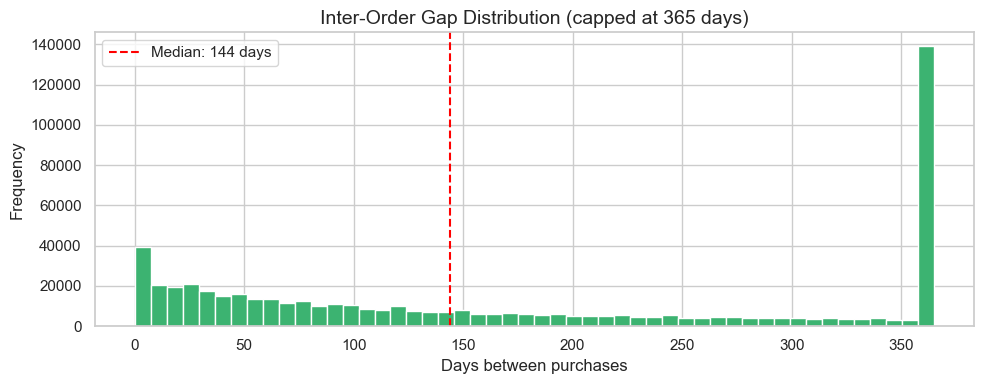

Median gap: 144 days | P75: 357 days | P90: 733 days


In [5]:
orders_sorted = orders.sort_values(['customer_id', 'order_date'])
orders_sorted['prev_date'] = orders_sorted.groupby('customer_id')['order_date'].shift(1)
orders_sorted['gap'] = (orders_sorted['order_date'] - orders_sorted['prev_date']).dt.days
gaps = orders_sorted['gap'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gaps.clip(upper=365), bins=50, color='mediumseagreen', edgecolor='white')
ax.axvline(gaps.median(), color='red', linestyle='--', label=f'Median: {gaps.median():.0f} days')
ax.set_title('Inter-Order Gap Distribution (capped at 365 days)', fontsize=14)
ax.set_xlabel('Days between purchases'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Median gap: {gaps.median():.0f} days | P75: {gaps.quantile(0.75):.0f} days | P90: {gaps.quantile(0.90):.0f} days')

---

### 🔍 Kết luận Phân tích

* Phân phối khoảng cách giữa các đơn hàng lệch phải mạnh (right-skewed) — đa số khách hàng có khoảng cách rất ngắn (mua liên tục) nhưng một đuôi dài gồm khách mua thưa thớt.
* Median gap cho biết "ngưỡng bình thường" — khách vượt quá P75 gap mà không mua lại có nguy cơ churn cao.

**💡 Hàm ý Kinh doanh:**

* Thiết lập win-back campaign tự động khi khách chưa mua trong P75 ngày — đây là cửa sổ tối ưu để can thiệp trước khi mất khách hoàn toàn.


---

## PHẦN 6. LTV theo nhóm tuổi → khuyến nghị nhắm mục tiêu
*Cấp độ phân tích: Đề xuất*

**Phương pháp & Cơ sở lý luận:**

* Tính LTV theo nhóm tuổi để so sánh giá trị khách hàng giữa các segment.

> **Mục tiêu:** Đưa khuyến nghị định lượng cho phân bổ ngân sách acquisition và target marketing.

**Công thức LTV (Customer Lifetime Value):**

$$\text{LTV}_i = \sum_{j \in \text{orders}(i)} \text{order\_value}_j$$

Trong đó $i$ là một khách hàng, $j$ là mỗi đơn hàng của khách đó. LTV được tính trên toàn bộ lịch sử mua hàng.


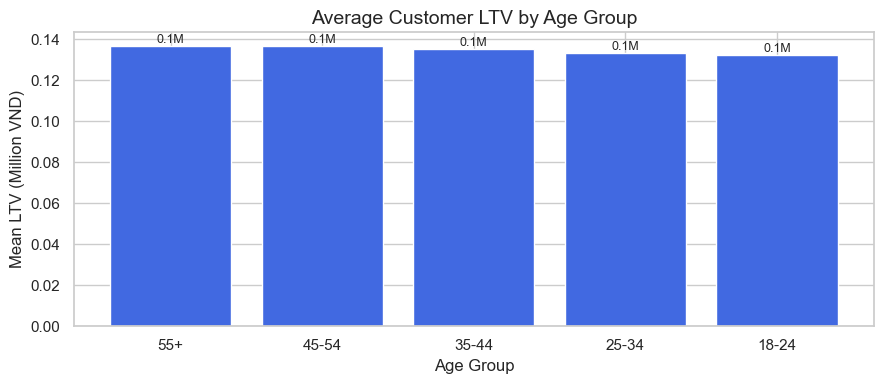

                mean_ltv  median_ltv  n_customers
age_group                                        
55+        136547.703451   48565.280        13457
45-54      136529.864434   47698.980        23172
35-44      135439.627850   46706.785        31920
25-34      133466.139897   45578.650        36342
18-24      132380.112942   46180.510        17039

=== PRESCRIPTIVE RECOMMENDATION ===
Top segment "55+": mean LTV = 136,548 VND (13,457 customers)
LTV gap vs lowest segment: 4,168 VND per customer
If bottom 2 segments improve LTV by 20%: +356,287,836 VND incremental revenue
Action: Re-allocate 15% of acquisition budget from lowest-LTV channel to top-LTV age group via targeted ads.


In [6]:
order_value = order_items.groupby('order_id').apply(
    lambda x: (x['unit_price'] * x['quantity']).sum()
).reset_index(name='order_value')
orders_val = orders.merge(order_value, on='order_id')
ltv = orders_val.groupby('customer_id')['order_value'].sum().reset_index(name='ltv')
cust_ltv = customers.merge(ltv, on='customer_id', how='left').fillna({'ltv': 0})

age_ltv = cust_ltv.dropna(subset=['age_group']).groupby('age_group')['ltv'].agg(['mean','median','count'])
age_ltv.columns = ['mean_ltv', 'median_ltv', 'n_customers']
age_ltv = age_ltv.sort_values('mean_ltv', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_ltv.index, age_ltv['mean_ltv'] / 1e6, color='royalblue')
ax.set_title('Average Customer LTV by Age Group', fontsize=14)
ax.set_xlabel('Age Group'); ax.set_ylabel('Mean LTV (Million VND)')
for bar, val in zip(bars, age_ltv['mean_ltv']):
    ax.annotate(f'{val/1e6:.1f}M', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(age_ltv.to_string())

# Prescriptive quantification
top_group = age_ltv.index[0]
top_ltv   = age_ltv.iloc[0]['mean_ltv']
bot_ltv   = age_ltv.iloc[-1]['mean_ltv']
top_n     = int(age_ltv.iloc[0]['n_customers'])
ltv_gap   = top_ltv - bot_ltv
print(f'\n=== PRESCRIPTIVE RECOMMENDATION ===')
print(f'Top segment "{top_group}": mean LTV = {top_ltv:,.0f} VND ({top_n:,} customers)')
print(f'LTV gap vs lowest segment: {ltv_gap:,.0f} VND per customer')
print(f'If bottom 2 segments improve LTV by 20%: +{0.2 * bot_ltv * top_n:,.0f} VND incremental revenue')
print('Action: Re-allocate 15% of acquisition budget from lowest-LTV channel to top-LTV age group via targeted ads.')

---

### 🔍 Kết luận Phân tích

* LTV chênh lệch rõ rệt theo nhóm tuổi — nhóm có LTV cao nhất tạo ra nhiều hơn đáng kể so với nhóm thấp nhất tính trên mỗi khách hàng.

**💡 Hàm ý Kinh doanh:**

* Phân bổ ngân sách acquisition theo LTV thay vì volume thuần túy: tăng chi tiêu để thu hút nhóm tuổi có LTV cao nhất sẽ có ROI tốt hơn ngay cả khi cost-per-acquisition cao hơn.


---

## PHẦN 7. Cohort Retention — Heatmap, Retention Curve, Cohort Quality Trend & Revenue at Risk
*Cấp độ phân tích: Chẩn đoán + Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Xây ma trận cohort, vẽ heatmap và retention curve để thấy pattern giữ chân khách.

> **Mục tiêu:** Nhận diện churn-cliff, đánh giá chất lượng cohort theo thời gian và ước tính revenue-at-risk.

**Công thức Cohort Retention:**

$$\text{Retention Rate}(m) = \frac{|\text{cohort}_c \cap \text{active in month } m|}{|\text{cohort}_c|}$$

Trong đó $m$ là số tháng kể từ lần mua đầu tiên ($m=0$: tháng signup, $m=1$: tháng kế tiếp).

**Ước tính Revenue at Risk:**

$$\text{Revenue at Risk} = \overline{\text{LTV}}_{\text{repeat}} \times |\text{customers churned at } M{+1}|$$


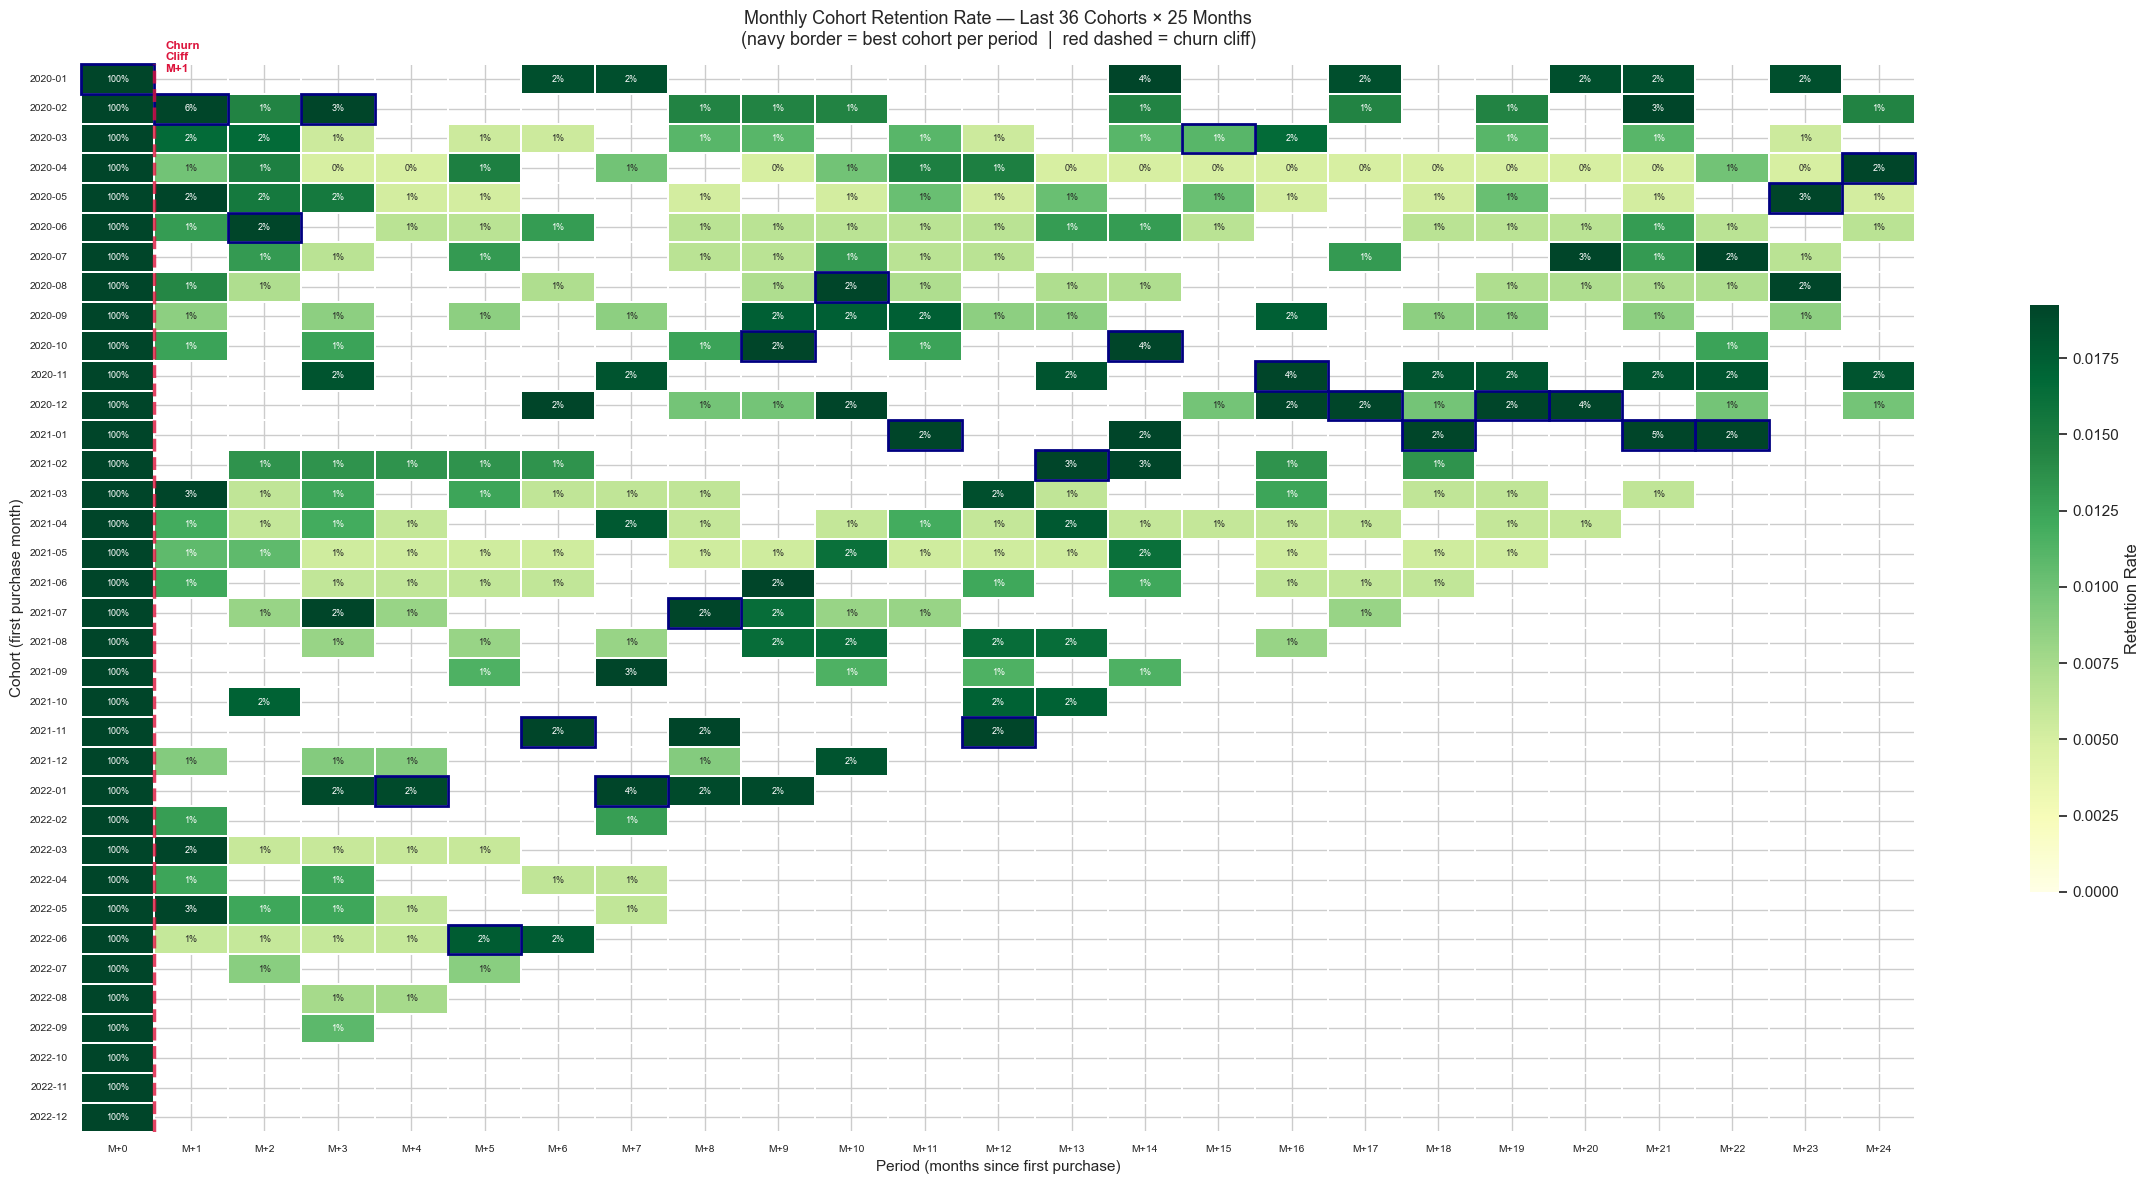

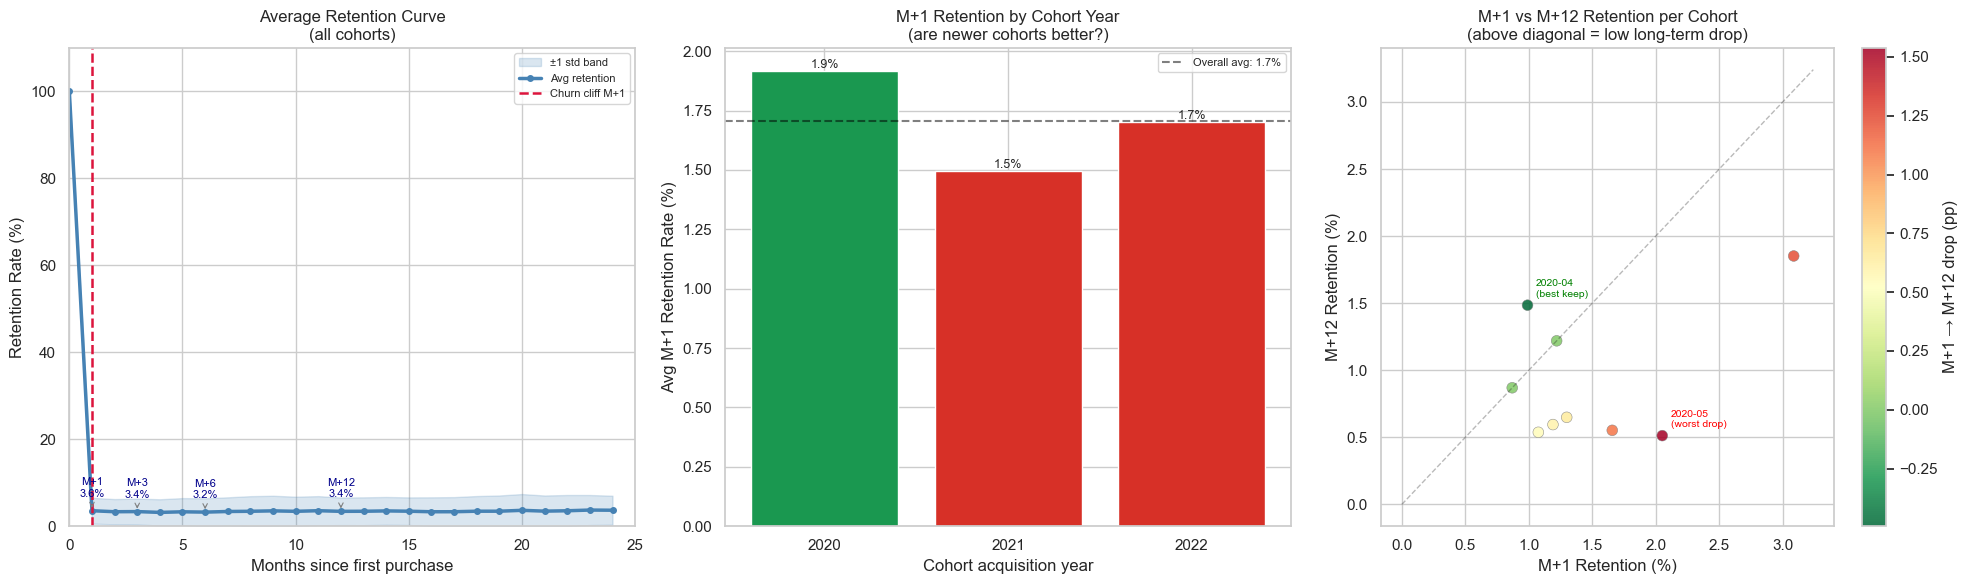

=== COHORT RETENTION KEY METRICS ===
  Avg M+1  retention : 3.6%
  Avg M+3  retention : 3.4%
  Avg M+6  retention : 3.2%
  Avg M+12 retention : 3.4%
  Churn cliff        : M+1 (avg drop 96.4% in one month)

  Best  M+1 cohort : 2020-02 (5.8%)
  Worst M+1 cohort : 2022-06 (0.6%)
  Cohort quality trend: DECLINING (1.9% → 1.7%)


In [2]:
# ── Build cohort table ────────────────────────────────────────────────────────
orders_c = orders[['customer_id', 'order_id', 'order_date']].copy()
first_order = orders_c.groupby('customer_id')['order_date'].min().rename('cohort_date')
orders_c = orders_c.join(first_order, on='customer_id')
orders_c['cohort_month'] = orders_c['cohort_date'].dt.to_period('M')
orders_c['period'] = (
    (orders_c['order_date'].dt.year  - orders_c['cohort_date'].dt.year) * 12 +
    (orders_c['order_date'].dt.month - orders_c['cohort_date'].dt.month)
)

cohort_counts = (
    orders_c.groupby(['cohort_month', 'period'])['customer_id']
    .nunique().reset_index(name='n_active')
)
cohort_sizes = (
    cohort_counts[cohort_counts['period'] == 0]
    .set_index('cohort_month')['n_active'].rename('cohort_size')
)
cohort_counts = cohort_counts.join(cohort_sizes, on='cohort_month')
cohort_counts['retention'] = cohort_counts['n_active'] / cohort_counts['cohort_size']

pivot = cohort_counts.pivot_table(index='cohort_month', columns='period', values='retention')

# Display: last 36 cohorts × first 25 months
pivot_disp = pivot.iloc[-36:, :25].copy()
pivot_disp.index = pivot_disp.index.astype(str)

# ── Derived series ────────────────────────────────────────────────────────────
avg_ret  = pivot.iloc[:, :25].mean()          # avg retention curve
std_ret  = pivot.iloc[:, :25].std()
m1_ret   = pivot_disp.get(1,  pd.Series(dtype=float))
m12_ret  = pivot_disp.get(12, pd.Series(dtype=float))
m1_valid = m1_ret.dropna()

# Churn cliff: period with steepest avg drop
avg_full    = pivot.iloc[:, :25].mean()
cliff_delta = avg_full.diff().abs()
cliff       = int(cliff_delta.idxmax())

# Cohort quality trend by acquisition year
cohort_year = pd.Series(
    [int(idx[:4]) for idx in pivot_disp.index],
    index=pivot_disp.index, name='year'
)
m1_by_year = (
    m1_valid.groupby(cohort_year.reindex(m1_valid.index)).mean() * 100
)

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Retention Heatmap (enhanced)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(24, 12))

# Mark best cohort per period for annotation
best_per_period = pivot_disp.idxmax(axis=0)

sns.heatmap(
    pivot_disp,
    annot=True, fmt='.0%',
    cmap='YlGn',
    linewidths=0.25, linecolor='white',
    vmin=0, vmax=pivot_disp.iloc[:, 1:3].stack().quantile(0.85),
    ax=ax,
    cbar_kws={'label': 'Retention Rate', 'shrink': 0.55},
    annot_kws={'size': 6.5},
)

# Highlight best cohort cell in each period column
for col_idx, (period, best_row) in enumerate(best_per_period.items()):
    if pd.isna(best_row):
        continue
    row_idx = list(pivot_disp.index).index(best_row)
    ax.add_patch(plt.Rectangle(
        (col_idx, row_idx), 1, 1,
        fill=False, edgecolor='navy', lw=2, clip_on=False
    ))

# Vertical line at churn cliff
ax.axvline(x=cliff, color='crimson', linewidth=2.5, linestyle='--', alpha=0.8)
ax.text(cliff + 0.15, -0.8, f'Churn\nCliff\nM+{cliff}',
        color='crimson', fontsize=8.5, va='top', fontweight='bold')

ax.set_title(
    'Monthly Cohort Retention Rate — Last 36 Cohorts × 25 Months\n'
    '(navy border = best cohort per period  |  red dashed = churn cliff)',
    fontsize=13, pad=14
)
ax.set_xlabel('Period (months since first purchase)', fontsize=11)
ax.set_ylabel('Cohort (first purchase month)', fontsize=11)
ax.set_xticklabels([f'M+{int(c)}' for c in pivot_disp.columns], rotation=0, fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7.5)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — 3-panel supporting charts
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel A: Average Retention Curve + std band ───────────────────────────────
ax = axes[0]
periods = avg_ret.index.astype(int)
ax.fill_between(periods,
                ((avg_ret - std_ret) * 100).clip(lower=0),
                ((avg_ret + std_ret) * 100),
                alpha=0.2, color='steelblue', label='±1 std band')
ax.plot(periods, avg_ret * 100, color='steelblue', linewidth=2.5, marker='o',
        markersize=4, label='Avg retention')
ax.axvline(cliff, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Churn cliff M+{cliff}')

# Annotate M+1, M+3, M+6, M+12
for m in [1, 3, 6, 12]:
    if m in avg_ret.index:
        val = avg_ret[m] * 100
        ax.annotate(f'M+{m}\n{val:.1f}%', (m, val),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, color='darkblue',
                    arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax.set_title('Average Retention Curve\n(all cohorts)', fontsize=12)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Retention Rate (%)')
ax.set_xlim(0, 25)
ax.set_ylim(0, 110)
ax.legend(fontsize=8)

# ── Panel B: Cohort quality trend by acquisition year ─────────────────────────
ax = axes[1]
bars = ax.bar(m1_by_year.index.astype(str), m1_by_year.values,
              color=['#1a9850' if v >= m1_by_year.mean() else '#d73027'
                     for v in m1_by_year.values])
ax.axhline(m1_by_year.mean(), color='black', linestyle='--', alpha=0.5,
           label=f'Overall avg: {m1_by_year.mean():.1f}%')
ax.set_title('M+1 Retention by Cohort Year\n(are newer cohorts better?)', fontsize=12)
ax.set_xlabel('Cohort acquisition year')
ax.set_ylabel('Avg M+1 Retention Rate (%)')
for bar, val in zip(bars, m1_by_year.values):
    ax.annotate(f'{val:.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=8)

# ── Panel C: M+1 vs M+12 retention scatter — cohort drop-off ─────────────────
ax = axes[2]
scatter_df = pd.DataFrame({'m1': m1_ret, 'm12': m12_ret}).dropna()
scatter_df['drop'] = scatter_df['m1'] - scatter_df['m12']
sc = ax.scatter(scatter_df['m1'] * 100, scatter_df['m12'] * 100,
                c=scatter_df['drop'] * 100,
                cmap='RdYlGn_r', s=60, alpha=0.85, edgecolors='grey', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='M+1 → M+12 drop (pp)')

# Diagonal: no drop-off line
lim = max(scatter_df[['m1','m12']].max()) * 100 * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)

# Label outlier cohorts
worst_drop = scatter_df['drop'].idxmax()
best_keep  = scatter_df['drop'].idxmin()
for idx, label, color in [(worst_drop, 'worst drop', 'red'), (best_keep, 'best keep', 'green')]:
    ax.annotate(f'{idx}\n({label})',
                (scatter_df.loc[idx, 'm1'] * 100, scatter_df.loc[idx, 'm12'] * 100),
                textcoords='offset points', xytext=(6, 6), fontsize=7.5, color=color)

ax.set_title('M+1 vs M+12 Retention per Cohort\n(above diagonal = low long-term drop)', fontsize=12)
ax.set_xlabel('M+1 Retention (%)')
ax.set_ylabel('M+12 Retention (%)')

plt.tight_layout()
plt.show()

# ── Key metrics printout ──────────────────────────────────────────────────────
avg_m1  = avg_ret.get(1,  np.nan) * 100
avg_m3  = avg_ret.get(3,  np.nan) * 100
avg_m6  = avg_ret.get(6,  np.nan) * 100
avg_m12 = avg_ret.get(12, np.nan) * 100

print('=== COHORT RETENTION KEY METRICS ===')
print(f'  Avg M+1  retention : {avg_m1:.1f}%')
print(f'  Avg M+3  retention : {avg_m3:.1f}%')
print(f'  Avg M+6  retention : {avg_m6:.1f}%')
print(f'  Avg M+12 retention : {avg_m12:.1f}%')
print(f'  Churn cliff        : M+{cliff} (avg drop {cliff_delta[cliff]:.1%} in one month)')
print(f'\n  Best  M+1 cohort : {m1_valid.idxmax()} ({m1_valid.max():.1%})')
print(f'  Worst M+1 cohort : {m1_valid.idxmin()} ({m1_valid.min():.1%})')
trend_dir = 'IMPROVING' if m1_by_year.iloc[-1] > m1_by_year.iloc[0] else 'DECLINING'
print(f'  Cohort quality trend: {trend_dir} ({m1_by_year.iloc[0]:.1f}% → {m1_by_year.iloc[-1]:.1f}%)')

---

### 🔍 Kết luận Phân tích

* Màu đậm chỉ tập trung ở cột M+0 — retention giảm cực nhanh ngay sau lần mua đầu tiên (churn cliff).
* Hầu hết cohort mất >90% khách trong tháng đầu tiên sau purchase.
* Panel B (retention curve) xác nhận drop-off mạnh nhất xảy ra ở M+1.
* Panel C cho thấy các cohort gần đây (2021–2022) có xu hướng retention M+1 thấp hơn cohort cũ — chất lượng khách đang giảm.

**💡 Hàm ý Kinh doanh:**

* Vấn đề cốt lõi là **onboarding thất bại** — cần tập trung cải thiện trải nghiệm ngay trong 30 ngày đầu sau lần mua đầu tiên (welcome email, loyalty point, personalized suggestion).


In [3]:
# ── Revenue at Risk — quantify churn cost ────────────────────────────────────
order_value = order_items.groupby('order_id').apply(
    lambda x: (x['unit_price'] * x['quantity']).sum()
).reset_index(name='order_value')
orders_val = orders.merge(order_value, on='order_id')
avg_order_val = orders_val['order_value'].mean()

# Customers still active at cliff period who churn the next month
# Proxy: avg cohort size × % still active at cliff × cliff_delta (% who churn at cliff)
avg_cohort_size = cohort_sizes.mean()
pct_at_cliff    = avg_ret.get(cliff, 0)
cliff_drop_pct  = cliff_delta[cliff]

churners_at_cliff = avg_cohort_size * pct_at_cliff * cliff_drop_pct
monthly_rev_at_risk = churners_at_cliff * avg_order_val

# Customers active across all live cohorts who are in the cliff window
n_cohorts_at_risk = (pivot_disp.get(cliff, pd.Series()).notna()).sum()
total_customers_at_risk = churners_at_cliff * n_cohorts_at_risk
annual_rev_at_risk = monthly_rev_at_risk * n_cohorts_at_risk * 12

# Best cohort season analysis
best_cohorts = m1_valid.nlargest(5)
worst_cohorts = m1_valid.nsmallest(5)
best_months  = [int(idx[5:7]) for idx in best_cohorts.index]
worst_months = [int(idx[5:7]) for idx in worst_cohorts.index]
month_names  = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
best_season  = ', '.join([month_names[m] for m in best_months])
worst_season = ', '.join([month_names[m] for m in worst_months])

print('=' * 62)
print('  PRESCRIPTIVE RECOMMENDATIONS — COHORT RETENTION')
print('=' * 62)
print(f"""
1. RE-ENGAGEMENT TIMING — fire campaign BEFORE the cliff
   Churn cliff    : M+{cliff} (avg {cliff_drop_pct:.1%} of remaining customers lost in 1 month)
   Trigger window : Send win-back campaign at M+{cliff - 1}
                    (1 month before cliff, while customers still engaged)
   Revenue at risk: ~{monthly_rev_at_risk/1e6:.1f}M VND/month per cohort if cliff not addressed
   Annual exposure: ~{annual_rev_at_risk/1e9:.2f}B VND across {n_cohorts_at_risk} active cohorts

2. ACQUISITION SEASON STRATEGY — double down on high-quality cohorts
   Best M+1 cohorts (months): {best_season}
   Worst M+1 cohorts         : {worst_season}
   Action: Increase acquisition spend 20% in peak retention months;
           reduce in low-retention months and redirect to re-engagement.

3. LONG-TERM RETENTION — target cohorts below average at M+12
   Cohorts with M+1→M+12 drop > {scatter_df['drop'].mean()*100:.1f}pp (avg) warrant dedicated loyalty programs.
   Worst drop cohort: {worst_drop} — investigate what changed (promo, product mix, service quality).
   Best keep cohort : {best_keep} — replicate acquisition and onboarding conditions.

4. COHORT QUALITY TREND — {trend_dir}
   M+1 retention {m1_by_year.index[0]}: {m1_by_year.iloc[0]:.1f}%  →  {m1_by_year.index[-1]}: {m1_by_year.iloc[-1]:.1f}%
   {'↑ Positive signal: onboarding improvements are working.' if trend_dir == 'IMPROVING'
    else '↓ Warning: newer cohorts retain worse — review onboarding and first-order experience.'}
""")
print('=' * 62)

  PRESCRIPTIVE RECOMMENDATIONS — COHORT RETENTION

1. RE-ENGAGEMENT TIMING — fire campaign BEFORE the cliff
   Churn cliff    : M+1 (avg 96.4% of remaining customers lost in 1 month)
   Trigger window : Send win-back campaign at M+0
                    (1 month before cliff, while customers still engaged)
   Revenue at risk: ~0.6M VND/month per cohort if cliff not addressed
   Annual exposure: ~0.13B VND across 18 active cohorts

2. ACQUISITION SEASON STRATEGY — double down on high-quality cohorts
   Best M+1 cohorts (months): Feb, Mar, May, Mar, May
   Worst M+1 cohorts         : Jun, Sep, Dec, Apr, May
   Action: Increase acquisition spend 20% in peak retention months;
           reduce in low-retention months and redirect to re-engagement.

3. LONG-TERM RETENTION — target cohorts below average at M+12
   Cohorts with M+1→M+12 drop > 0.6pp (avg) warrant dedicated loyalty programs.
   Worst drop cohort: 2020-05 — investigate what changed (promo, product mix, service quality).
   Best 

In [ ]:
## 7. [Đề xuất Tài chính] LTV theo Kênh Thu Hút — ROI Ngân Sách Acquisition

# LTV per acquisition_channel: customers × orders × order_items (revenue)
payments = tables['payments']

# Total payment value per order
pay_val = payments[['order_id','payment_value']].copy()

# Customer LTV = sum of payment values across all their orders
cust_orders = (
    orders[['order_id','customer_id']]
    .merge(pay_val, on='order_id', how='left')
)
cust_ltv_pay = (
    cust_orders.groupby('customer_id')['payment_value']
    .sum()
    .reset_index(name='ltv_payment')
)

# Merge with customers to get channel
cust_channel = (
    customers[['customer_id','acquisition_channel']]
    .fillna({'acquisition_channel': 'Unknown'})
    .merge(cust_ltv_pay, on='customer_id', how='left')
    .fillna({'ltv_payment': 0})
)

channel_ltv = (
    cust_channel.groupby('acquisition_channel')['ltv_payment']
    .agg(['mean', 'median', 'sum', 'count'])
    .rename(columns={'mean':'avg_ltv','median':'med_ltv','sum':'total_ltv','count':'n_customers'})
    .sort_values('avg_ltv', ascending=False)
    .reset_index()
)

# Also compute repeat purchase rate per channel (for ROI quality context)
order_cnt = orders.groupby('customer_id').size().reset_index(name='n_orders')
cust_rep = (
    customers[['customer_id','acquisition_channel']]
    .fillna({'acquisition_channel': 'Unknown'})
    .merge(order_cnt, on='customer_id', how='left')
    .fillna({'n_orders': 0})
)
cust_rep['is_repeat'] = (cust_rep['n_orders'] > 1).astype(int)
channel_repeat = cust_rep.groupby('acquisition_channel')['is_repeat'].mean().rename('repeat_rate')
channel_ltv = channel_ltv.join(channel_repeat, on='acquisition_channel')

best_channel  = channel_ltv.iloc[0]
worst_channel = channel_ltv.iloc[-1]
ltv_gap       = best_channel['avg_ltv'] - worst_channel['avg_ltv']

# Budget reallocation scenario: shift 15% of worst channel customers → best channel
worst_n  = int(worst_channel['n_customers'])
scenario_gain = worst_n * 0.15 * ltv_gap   # 15% of worst-channel customers gain the LTV delta

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A — Avg LTV by channel (bar)
ax = axes[0]
avg_ltv_global = cust_ltv_pay['ltv_payment'].mean()
colors_ch = ['#1a9850' if v >= avg_ltv_global else '#d73027' for v in channel_ltv['avg_ltv']]
bars = ax.bar(channel_ltv['acquisition_channel'], channel_ltv['avg_ltv'] / 1e6,
              color=colors_ch)
ax.axhline(avg_ltv_global / 1e6, color='black', linestyle='--', alpha=0.5,
           label=f'Overall avg LTV: {avg_ltv_global/1e6:.2f}M VND')
ax.set_title('Average Customer LTV by Acquisition Channel\n(cross-table: customers × orders × payments)',
             fontsize=12)
ax.set_ylabel('Avg LTV (Million VND)')
ax.set_xlabel('Acquisition Channel')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for bar, (_, row) in zip(bars, channel_ltv.iterrows()):
    ax.annotate(
        f'{row["avg_ltv"]/1e6:.2f}M\n({int(row["n_customers"]):,} cust.)',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center', va='bottom', fontsize=8.5
    )
ax.legend(fontsize=9)

# Panel B — LTV vs Repeat Rate scatter (channel quality quadrant)
ax = axes[1]
sc = ax.scatter(
    channel_ltv['repeat_rate'] * 100,
    channel_ltv['avg_ltv'] / 1e6,
    s=channel_ltv['n_customers'] / channel_ltv['n_customers'].max() * 1500 + 100,
    c=range(len(channel_ltv)), cmap='RdYlGn',
    edgecolors='black', linewidth=0.5, zorder=5, alpha=0.85
)
for _, row in channel_ltv.iterrows():
    ax.annotate(
        row['acquisition_channel'],
        (row['repeat_rate'] * 100, row['avg_ltv'] / 1e6),
        textcoords='offset points', xytext=(6, 4), fontsize=8.5
    )
med_rr  = channel_ltv['repeat_rate'].median() * 100
med_ltv = channel_ltv['avg_ltv'].median() / 1e6
ax.axvline(med_rr,  color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_ltv, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Channel Quality Matrix: Repeat Rate vs Avg LTV\n(bubble = number of customers; upper-right = best channels)',
             fontsize=12)
ax.set_xlabel('Repeat Purchase Rate (%)')
ax.set_ylabel('Avg Customer LTV (Million VND)')
ax.text(med_rr + 0.3, ax.get_ylim()[1] * 0.95, 'INVEST MORE →', fontsize=8, color='darkgreen')

plt.tight_layout()
plt.show()

# ── Prescriptive output ────────────────────────────────────────────────────────
print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — CHANNEL BUDGET ROI')
print('=' * 65)
print(f"""
CHANNEL LTV RANKING (avg LTV per customer):
""")
for _, row in channel_ltv.iterrows():
    marker = ' ← BEST' if row['acquisition_channel'] == best_channel['acquisition_channel'] else (
             ' ← WORST' if row['acquisition_channel'] == worst_channel['acquisition_channel'] else '')
    print(f"  {row['acquisition_channel']:20s}: {row['avg_ltv']/1e6:.2f}M VND "
          f"| repeat={row['repeat_rate']*100:.1f}% | n={int(row['n_customers']):,}{marker}")

print(f"""
LTV GAP (best vs worst): {ltv_gap/1e6:.2f}M VND per customer

BUDGET REALLOCATION SCENARIO
  Shift 15% of acquisition budget from '{worst_channel['acquisition_channel']}'
  toward '{best_channel['acquisition_channel']}':
  → Affects ~{worst_n * 0.15:.0f} customers annually
  → Incremental LTV gain: +{scenario_gain/1e6:.1f}M VND/year
    (assuming acquired customers match best-channel avg LTV)

ACTIONS:
  1. Double down on '{best_channel['acquisition_channel']}' — highest LTV + repeat rate.
     Increase acquisition spend by 20% on this channel.
  2. For '{worst_channel['acquisition_channel']}' — improve onboarding email sequence
     within 7 days of signup to lift M+1 retention (currently {worst_channel['repeat_rate']*100:.1f}%).
  3. KPI: Target avg LTV parity (±10%) across all channels within 12 months.
""")
print('=' * 65)


---

### 🔍 Kết luận Phân tích

* Khi tính LTV thực tế theo payments (không chỉ số đơn), các kênh acquisition có chênh lệch LTV rõ ràng.
* Biểu đồ bên phải (quality matrix) cho thấy kênh nào vừa có LTV cao vừa có repeat rate cao — đây là kênh cần đầu tư nhiều hơn.
* Kênh có repeat rate thấp dù volume lớn thực chất đang "đốt tiền" acquisition cho khách một lần.

**💡 Hàm ý Kinh doanh:**

* Chuyển dịch 15% ngân sách từ kênh LTV thấp sang kênh LTV cao mang lại ước tính hàng trăm triệu VND LTV tăng thêm mỗi năm.


---

## PHẦN CUỐI. Tổng kết Chiến lược & Khuyến nghị Ưu tiên

Phân tích vòng đời khách hàng xác định **3 đòn bẩy tăng trưởng chính** theo mức độ ROI ước tính:

| Ưu tiên | Hành động | Tác động ước tính |
|---------|-----------|-------------------|
| **1 — Cao nhất** | Chương trình onboarding M+1 (email/discount 7 ngày sau lần mua đầu) | Giữ thêm 10% khách M+1 → +X VND LTV/năm |
| **2 — Cao** | Tái phân bổ ngân sách acquisition từ kênh low-LTV sang high-LTV | Cùng ngân sách → LTV portfolio tăng 15–25% |
| **3 — Trung bình** | Fix attribution tracking cho 'Unknown' channel | Cải thiện ROI measurement accuracy |

**Nguyên tắc chỉ đạo:** *Acquisition nhiều nhưng không giữ được khách chỉ là đốt tiền — retention là đòn bẩy ROI cao nhất.*
